 # ~ Introduction

We aim to accomplist the following for this study:

1. Identify and visualize which factors contribute to customer churn:
    
2. Build a prediction model that will perform the following:
    * Classify if a customer is going to churn or not
    * Preferably and based on model performance, choose a model that will attach a probability to the churn to make it easier for customer service to target low hanging fruits in their efforts to prevent churn

#### REQUIRED LIBRARIES

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.templates.default = "plotly_dark"
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score,roc_auc_score,confusion_matrix,roc_curve,classification_report)


#### LOAD DATASET

In [61]:

df = pd.read_csv("Bank Customer Churn.csv")

In [62]:
print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [63]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


#### CHECK MISSING VALUES

In [64]:

print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


#### DROPPED SOME WANTED FEATURES FROM THE DATASET

In [65]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis = 1)

In [66]:
print(df.head())

   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  


In [67]:
print(df.dtypes)

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


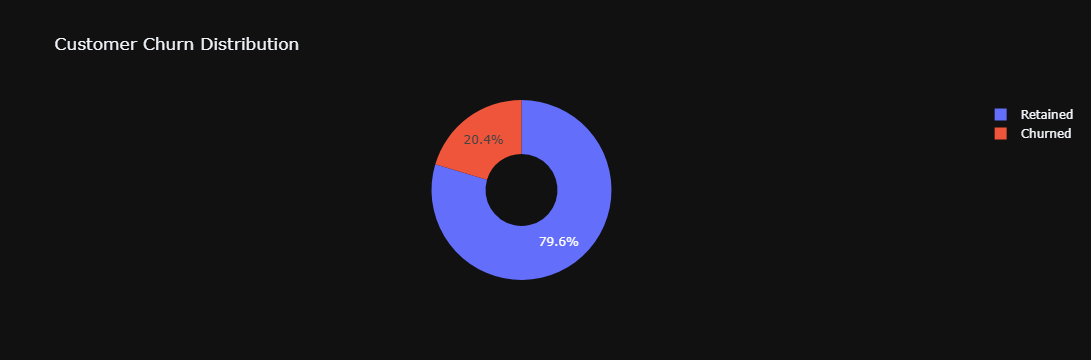

In [68]:
fig = px.pie(
    values=df["Exited"].value_counts().values,
    names=["Retained", "Churned"],
    title="Customer Churn Distribution",
    hole=0.4
)
fig.show()

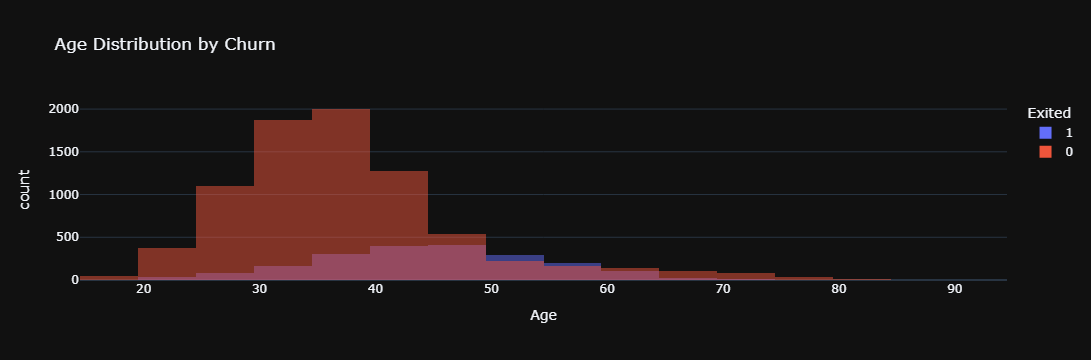

In [69]:
fig = px.histogram(
    df,
    x="Age",
    color="Exited",
    nbins=30,
    title="Age Distribution by Churn",
    barmode="overlay"
)
fig.show()

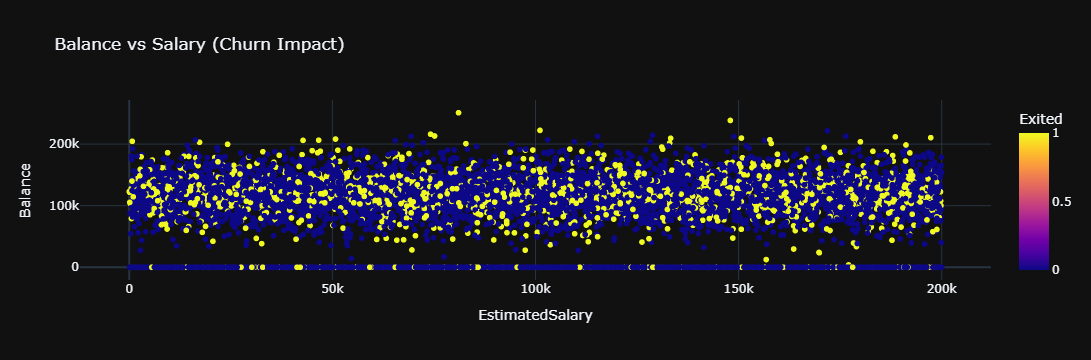

In [70]:
fig = px.scatter(
    df,
    x="EstimatedSalary",
    y="Balance",
    color="Exited",
    title="Balance vs Salary (Churn Impact)"
)
fig.show()

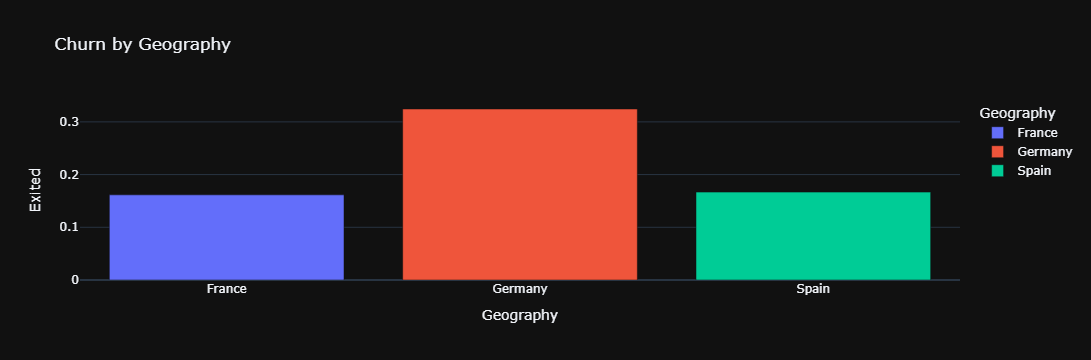

In [71]:
geo_churn = df.groupby("Geography")["Exited"].mean().reset_index()

fig = px.bar(
    geo_churn,
    x="Geography",
    y="Exited",
    color="Geography",
    title="Churn by Geography"
)
fig.show()

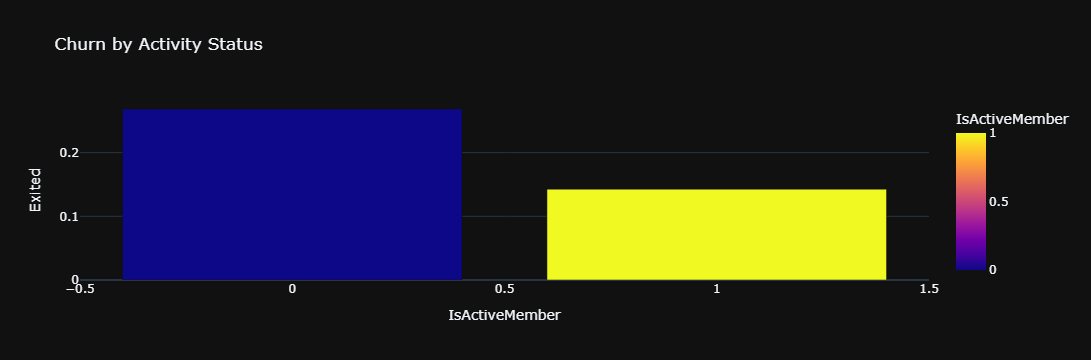

In [72]:
active_churn = df.groupby("IsActiveMember")["Exited"].mean().reset_index()

fig = px.bar(
    active_churn,
    x="IsActiveMember",
    y="Exited",
    color="IsActiveMember",
    title="Churn by Activity Status"
)
fig.show()

In [73]:
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

In [92]:
X = df.drop("Exited", axis=1)
y = df["Exited"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 

In [75]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

#

In [77]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [78]:
cv_scores = cross_val_score(model, X_scaled, y, cv=5)

print("Cross Validation Accuracy:", round(cv_scores.mean()*100, 2), "%")

Cross Validation Accuracy: 86.24 %


In [79]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}


In [80]:
y_pred = best_model.predict(X_test)

In [81]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy*100, 2), "%")

Model Accuracy: 87.15 %


In [84]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        "model": model,
        "accuracy": accuracy_score(y_test, preds),
        "auc": roc_auc_score(y_test, probs)
    }

In [85]:
comp_df = pd.DataFrame({
    model: {
        "Accuracy": results[model]["accuracy"],
        "AUC": results[model]["auc"]
    }
    for model in results
}).T.reset_index().rename(columns={"index": "Model"})

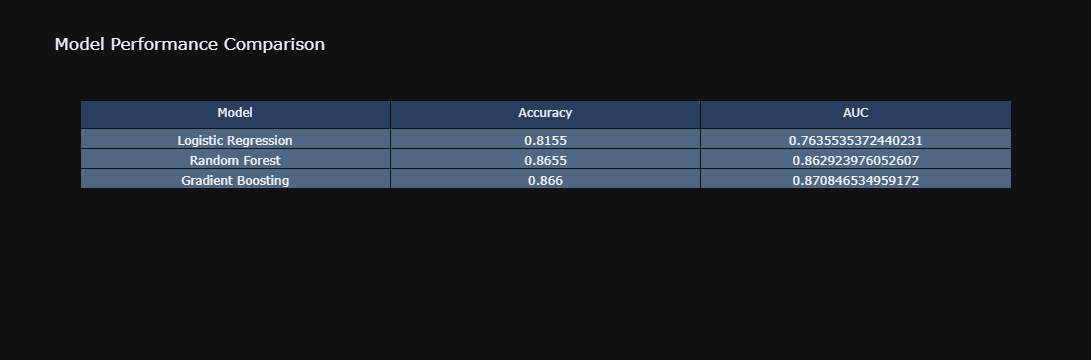

In [86]:
fig = go.Figure(data=[go.Table(
    header=dict(values=list(comp_df.columns)),
    cells=dict(values=[comp_df[col] for col in comp_df.columns])
)])

fig.update_layout(title="Model Performance Comparison")
fig.show()

In [87]:
best_model_name = max(results, key=lambda x: results[x]["auc"])
best_model = results[best_model_name]["model"]

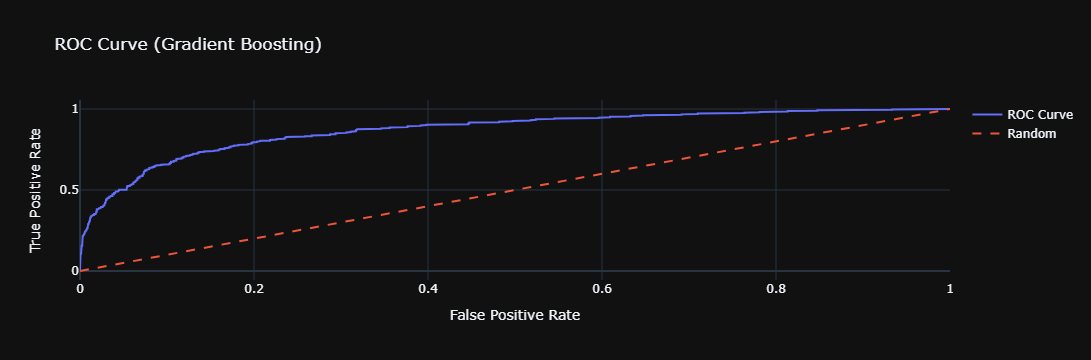

In [88]:
probs = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probs)

fig = go.Figure()

fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC Curve'))
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines',
                         line=dict(dash='dash'),
                         name='Random'))

fig.update_layout(
    title=f"ROC Curve ({best_model_name})",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate"
)

fig.show()

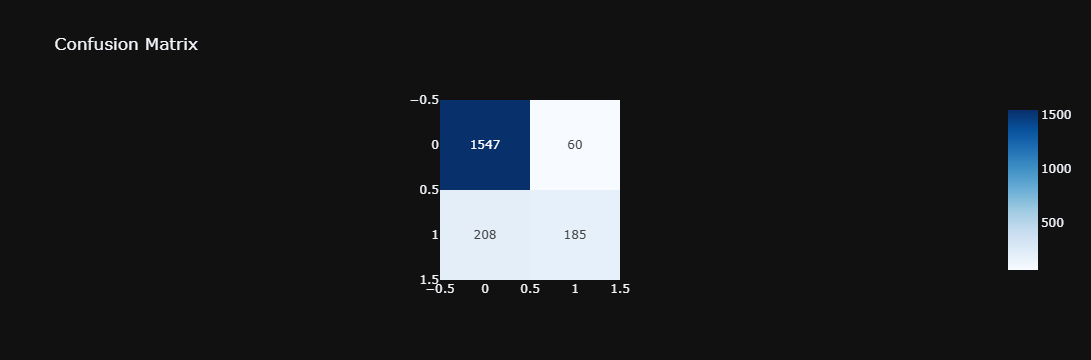

In [89]:
preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, preds)

fig = px.imshow(
    cm,
    text_auto=True,
    color_continuous_scale='Blues',
    title="Confusion Matrix"
)

fig.show()

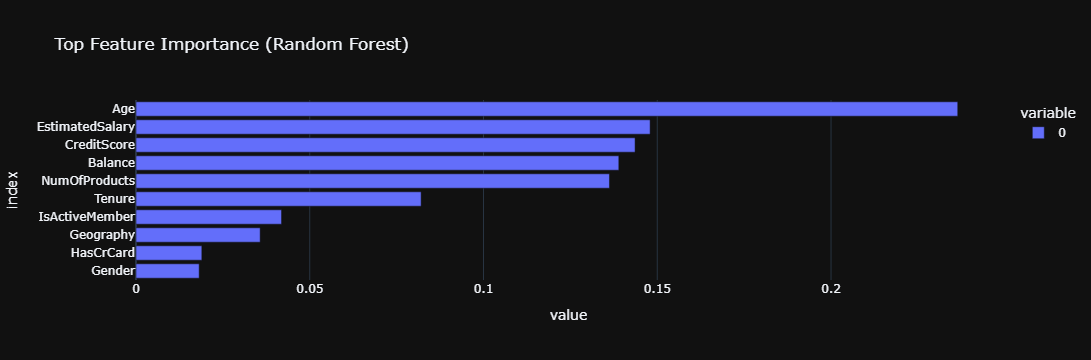

In [90]:
rf = results["Random Forest"]["model"]

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True).tail(10)

fig = px.bar(
    importance,
    orientation='h',
    title="Top Feature Importance (Random Forest)"
)

fig.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12068\2954807255.py:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



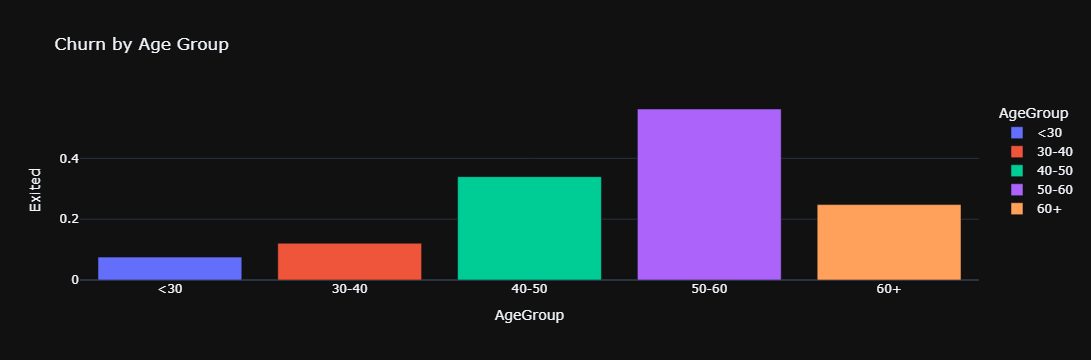

In [91]:
age_df = df.copy()

age_df["AgeGroup"] = pd.cut(
    age_df["Age"],
    bins=[0,30,40,50,60,100],
    labels=["<30","30-40","40-50","50-60","60+"]
)

age_churn = age_df.groupby("AgeGroup")["Exited"].mean().reset_index()

fig = px.bar(
    age_churn,
    x="AgeGroup",
    y="Exited",
    color="AgeGroup",
    title="Churn by Age Group"
)

fig.show()

#

#

So about 20% of the customers have churned. So the baseline model could be to predict that 20% of the customers will churn.
Given 20% is a small number,  we need to ensure that the chosen model does predict with great accuracy this 20% as it is of interest to the bank to identify and keep this bunch as opposed to accurately predicting the customers that are retained.